In [23]:
# Find the channel with the highest FFT peak magnitude for two timestamps within a km range
# Reuses helpers and directory variables defined earlier.

import os
import glob
import h5py
import numpy as np
from datetime import datetime, timedelta, timezone

from Helpers import extract_metadata, find_start_file
directory = "../raw_data/GC_data/20250702"
# Inputs: two timestamps (HHMMSS) to compare
TIMESTAMPS = ["121936", "122236","122206","122136"]
DIRECTORY = directory if 'directory' in globals() else "../data/GC_data/20250702"

# FFT parameters
DURATION_SEC = 30           # seconds of data per timestamp to analyze
MAX_FREQ_HZ = 200           # cap plotting/analysis to Nyquist or this value

# New: km interval to restrict channels
KM_MIN = 20               # km
KM_MAX = 28.0               # km

# Helper: load contiguous block starting at timestamp for all channels
def load_block_all_channels(file_paths, start_time_str, duration_sec):
    # Find starting file index using existing helper
    try:
        _, start_index = find_start_file(file_paths, start_time_str)
    except Exception as e:
        raise RuntimeError(f"Could not locate start time {start_time_str}: {e}")

    # Get metadata from first file to compute required number of files
    _, dt, dx, channels, num_samples_first = extract_metadata(file_paths[start_index])
    fs = 1.0 / dt
    file_duration = num_samples_first * dt
    import math
    n_files_needed = max(1, math.ceil(duration_sec / file_duration))
    sel_paths = file_paths[start_index : min(start_index + n_files_needed, len(file_paths))]

    # Load all channels from selected files and concatenate on time axis
    data_list = []
    for fp in sel_paths:
        with h5py.File(fp, 'r') as f:
            d = f['data'][:]  # [time, channels]
        data_list.append(d)
    data = np.vstack(data_list)
    # Trim to exact duration if overshot
    samples_needed = int(round(duration_sec / dt))
    if data.shape[0] > samples_needed:
        data = data[:samples_needed, :]
    return data, dt, fs, dx, channels

# Compute per-channel FFT peak magnitude and dominant frequency
def channel_fft_peaks(data, dt, max_freq_hz=None):
    N = data.shape[0]
    fs = 1.0 / dt
    freqs = np.fft.rfftfreq(N, dt)
    X = np.fft.rfft(data, axis=0)  # shape [freq_bins, channels]
    mags = np.abs(X)
    if max_freq_hz is not None:
        mask = freqs <= min(max_freq_hz, fs/2)
        freqs = freqs[mask]
        mags = mags[mask, :]
    # Peak per channel
    peak_idx = np.argmax(mags, axis=0)
    peak_mag = mags[peak_idx, np.arange(mags.shape[1])]
    peak_freq = freqs[peak_idx]
    return peak_mag, peak_freq

# Main: iterate timestamps and find best channel within km range

file_paths_all = sorted(glob.glob(os.path.join(DIRECTORY, '*.hdf5')))
if not file_paths_all:
    raise FileNotFoundError(f"No HDF5 files found in {DIRECTORY}")

# Extract metadata once to compute distances for masking
_, dt_meta, dx_meta, channels_meta, _ = extract_metadata(file_paths_all[0])
distances_km_full = (channels_meta * dx_meta) / 1000.0
km_mask = (distances_km_full >= KM_MIN) & (distances_km_full <= KM_MAX)
if not np.any(km_mask):
    raise ValueError(f"No channels found in km interval [{KM_MIN}, {KM_MAX}] km")

results = []
for ts in TIMESTAMPS:
    data, dt, fs, dx, channels = load_block_all_channels(file_paths_all, ts, DURATION_SEC)
    # Align mask with loaded channels; validate same channel layout
    if not np.array_equal(channels, channels_meta):
        # Fallback: recompute distances from current channels
        distances_km = (channels * dx) / 1000.0
        local_mask = (distances_km >= KM_MIN) & (distances_km <= KM_MAX)
    else:
        local_mask = km_mask
    # Apply km mask to columns
    data_masked = data[:, local_mask]
    masked_channels = channels[local_mask]
    if data_masked.shape[1] == 0:
        raise ValueError(f"No channels within km range for timestamp {ts}")
    peak_mag, peak_freq = channel_fft_peaks(data_masked, dt, MAX_FREQ_HZ)
    # Argmax across masked channels
    best_local_idx = int(np.argmax(peak_mag))
    best_channel_global_index = int(masked_channels[best_local_idx])
    best_distance_km = float(best_channel_global_index * dx) / 1000.0
    results.append({
        'timestamp': ts,
        'best_channel_index': best_channel_global_index,
        'best_channel_distance_km': best_distance_km,
        'peak_magnitude': float(peak_mag[best_local_idx]),
        'dominant_frequency_hz': float(peak_freq[best_local_idx]),
        'analyzed_seconds': int(DURATION_SEC),
        'sample_rate_hz': float(fs),
        'km_min': float(KM_MIN),
        'km_max': float(KM_MAX)
    })

print(f"Per-timestamp best channels within [{KM_MIN}, {KM_MAX}] km (highest FFT peak magnitude):")
for r in results:
    print(f"  {r['timestamp']}: channel {r['best_channel_index']} at {r['best_channel_distance_km']:.3f} km | "
          f"peak {r['peak_magnitude']:.3g} at {r['dominant_frequency_hz']:.2f} Hz")

# Optional: check if the same channel is best in both timestamps
if len(results) == 2:
    if results[0]['best_channel_index'] == results[1]['best_channel_index']:
        print(f"Same best channel across both: {results[0]['best_channel_index']}")
    else:
        print("Different best channels across timestamps:")
        print(f"  {results[0]['timestamp']} -> {results[0]['best_channel_index']}")
        print(f"  {results[1]['timestamp']} -> {results[1]['best_channel_index']}")

Per-timestamp best channels within [20, 28.0] km (highest FFT peak magnitude):
  121936: channel 24218 at 24.734 km | peak 1.19e+06 at 57.43 Hz
  122236: channel 23214 at 23.708 km | peak 1.8e+06 at 44.70 Hz
  122206: channel 23630 at 24.133 km | peak 2.88e+06 at 43.33 Hz
  122136: channel 24210 at 24.726 km | peak 1.38e+06 at 40.97 Hz


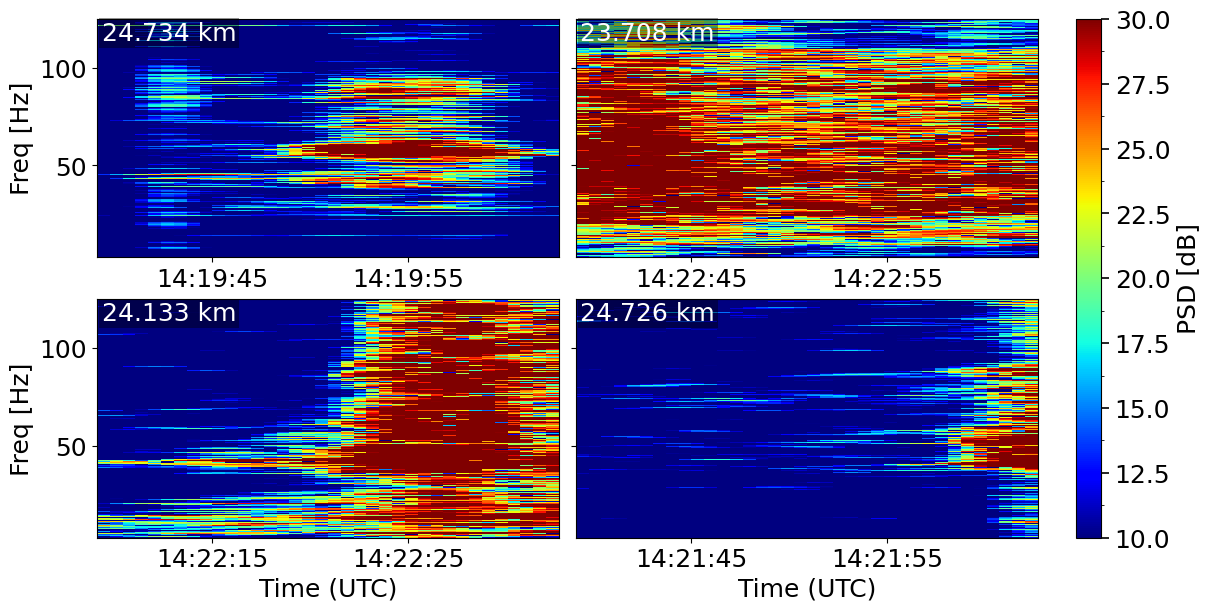

Spectrogram grid built from Cell 1 results (channel IDs):
  121936: requested channel ID 24218
  122236: requested channel ID 23214
  122206: requested channel ID 23630
  122136: requested channel ID 24210
Note: If a channel ID wasn't present, the nearest by distance was used; titles were removed by request.
Each panel: 3 files (~30s), Nfft=4096, overlap=0.9


In [41]:
# Multi-spectrogram comparison: use channels discovered in Cell 1 as channel IDs (not zero-based indices)
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator
import glob
import h5py
from datetime import datetime, timedelta, timezone

from Helpers import *

# Ensure we use the exact same directory as Cell 1
try:
    DIRECTORY
except NameError:
    DIRECTORY = "../raw_data/GC_data/20250702"

file_paths = sorted(glob.glob(os.path.join(DIRECTORY, '*.hdf5')))
if not file_paths:
    raise FileNotFoundError(f"No HDF5 files found in {DIRECTORY}")

# Pull timestamps and channels from Cell 1 results
try:
    TIMESTAMPS = [r['timestamp'] for r in results]
    CHANNEL_IDS_FROM_CELL1 = [int(r['best_channel_index']) for r in results]  # Treat as channel IDs from metadata
except Exception as e:
    raise RuntimeError("Cell 1 must be run first to populate 'results' with best channels.")

# Load metadata to get the channels array (actual channel IDs)
_, dt_meta, dx_meta, channels_meta, _ = extract_metadata(file_paths[0])
max_channel_index = len(channels_meta) - 1

def channel_id_to_index(channel_ids_array, requested_id):
    """Map a channel ID (value in channels array) to its zero-based column index. If not found, choose nearest by distance."""
    matches = np.where(channel_ids_array == requested_id)[0]
    if matches.size > 0:
        return int(matches[0]), False
    # Nearest by distance: convert IDs to km distance using dx_meta, find closest distance to requested_id*dx
    distances_m = channel_ids_array * dx_meta
    target_m = requested_id * dx_meta
    idx = int(np.argmin(np.abs(distances_m - target_m)))
    return idx, True

# Ensure alignment
if len(TIMESTAMPS) != len(CHANNEL_IDS_FROM_CELL1):
    raise ValueError("Mismatch: number of timestamps and discovered channels differ.")

SPECTROGRAM_CHUNK_SIZE = 3   # 3 files × 10s = ~30 seconds

# Spectrogram plotting params
fmax = 125
vmin_db = 10
vmax_db = 30
time_tolerance = 0.05
Nfft = 4096
OVERLAP = 0.9

def find_start_index(file_paths, ts_str):
    try:
        _, start_idx = find_start_file(file_paths, ts_str)
        return start_idx
    except Exception as e:
        raise RuntimeError(f"Could not locate start time {ts_str}: {e}")

def load_channel_block(file_paths, ts_str, requested_channel_id):
    start_idx = find_start_index(file_paths, ts_str)
    sel_paths = file_paths[start_idx : min(start_idx + SPECTROGRAM_CHUNK_SIZE, len(file_paths))]
    if len(sel_paths) < SPECTROGRAM_CHUNK_SIZE:
        print(f"Warning: Only {len(sel_paths)} files found starting at {ts_str}")
    all_channel_data = []
    file_start_time = None
    dt_ref = None
    channels_ref = None
    file_duration = None
    processed_files_count = 0
    channel_distance_km = None
    dx_last = None
    ch_index_used = None
    # Determine zero-based index for the requested channel ID using the first file's metadata
    try:
        s_time0, s_dt0, s_dx0, s_channels0, s_num0 = extract_metadata(sel_paths[0])
        idx0, was_mapped = channel_id_to_index(s_channels0, requested_channel_id)
        ch_index_used = idx0
        if was_mapped:
            print(f"[WARN] Channel ID {requested_channel_id} not found; using nearest at index {idx0} (ID {int(s_channels0[idx0])})")
    except Exception as e:
        # Fallback: assume ID equals index
        ch_index_used = requested_channel_id
    for i, file_path in enumerate(sel_paths):
        try:
            current_start_time, current_dt, dx, current_channels, num_samples = extract_metadata(file_path)
        except Exception as e:
            print(f"Skipping metadata for {file_path}: {e}")
            continue
        dx_last = dx
        current_file_duration = num_samples * current_dt
        if file_start_time is None:
            file_start_time = current_start_time
            dt_ref = current_dt
            channels_ref = current_channels
            file_duration = current_file_duration
        if not np.isclose(current_dt, dt_ref, atol=1e-12):
            print(f"Skipping {os.path.basename(file_path)}: dt mismatch ({current_dt} != {dt_ref})")
            continue
        if ch_index_used >= len(current_channels):
            print(f"Selected channel index {ch_index_used} out of range for {os.path.basename(file_path)} (max {len(current_channels)-1})")
            break
        expected_start = file_start_time + processed_files_count * file_duration
        if not np.isclose(current_start_time, expected_start, atol=time_tolerance):
            print(f"Skipping {os.path.basename(file_path)}: start {current_start_time} not contiguous (expected {expected_start})")
            break
        try:
            with h5py.File(file_path, "r") as f:
                channel_data = f["data"][:, ch_index_used]
                all_channel_data.append(channel_data)
                processed_files_count += 1
        except Exception as e:
            print(f"Skipping file {os.path.basename(file_path)} due to read error: {e}")
    if not all_channel_data:
        return None, None, None, None, None, None
    combined = np.concatenate(all_channel_data)
    fs = 1.0 / dt_ref
    # Compute km distance from channel ID (preferred) if available, else from index
    try:
        ch_id_used = int(channels_ref[ch_index_used])
    except Exception:
        ch_id_used = requested_channel_id
    distance_km = (ch_id_used * dx_last) / 1000.0 if dx_last is not None else None
    return combined, fs, dt_ref, file_start_time, distance_km, ch_id_used, ch_index_used

# Build grid: one column per timestamp-channel pair
n = len(TIMESTAMPS)
rows = int(np.ceil(n / 2))
cols = 2 if n > 1 else 1
fig, axes = plt.subplots(rows, cols, figsize=(12, 6), sharex=False, sharey=True, constrained_layout=True)
axes = np.array(axes).reshape(rows, cols)

idx = 0
last_im = None
for r in range(rows):
    for c in range(cols):
        if idx >= n:
            axes[r, c].set_axis_off()
            continue
        ts = TIMESTAMPS[idx]
        ch_id = CHANNEL_IDS_FROM_CELL1[idx]
        ax = axes[r, c]
        data, fs, dt_ref, file_start_time, channel_distance_km, ch_id_used, ch_index_used = load_channel_block(file_paths, ts, ch_id)
        if data is None:
            ax.text(0.5, 0.5, "No data", ha='center', va='center')
            ax.set_axis_off()
            idx += 1
            continue
        # Compute spectrogram
        tspect, fspect, psd = compute_spectrogram(
            data,
            fs,
            Nfft=Nfft,
            overlap=OVERLAP,
            file_time=file_start_time
)
        # Plot
        tspect_num = mdates.date2num(tspect)
        T, F = np.meshgrid(tspect_num, fspect)
        last_im = ax.pcolormesh(T, F, psd, cmap="jet", vmin=vmin_db, vmax=vmax_db, shading="auto")
        ax.set_ylim(3, fmax)
        ax.xaxis_date()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        # X ticks at 10-second increments
        ax.xaxis.set_major_locator(mdates.SecondLocator(interval=10))
        # Add km stamp at top-left
        if channel_distance_km is not None:
            ax.text(0.01, 0.99, f"{channel_distance_km:.3f} km", transform=ax.transAxes, ha='left', va='top', fontsize=18, color='white', bbox=dict(facecolor='black', alpha=0.4, edgecolor='none', pad=2))
        # Remove titles as requested
        # ax.set_title(f"{ts} | channel ID {ch_id_used} @ {channel_distance_km:.3f} km (index {ch_index_used})", fontsize=10)
        if r == rows - 1:
            ax.set_xlabel("Time (UTC)", fontsize=18)
        if c == 0:
            ax.set_ylabel("Freq [Hz]", fontsize=18)
        # Increase tick label sizes
        ax.tick_params(axis='both', which='major', labelsize=18)
        idx += 1

# Colorbar (ensure it does not overlap with subplots)
if last_im is not None:
    cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    cbar.set_label("PSD [dB]", fontsize=18)
    # Match tick label sizes to axes
    cbar.ax.tick_params(labelsize=18, which='major', length=6, width=1.2)
    # Minor ticks between majors
    cbar.ax.yaxis.set_minor_locator(AutoMinorLocator(2))

plt.show()

print("Spectrogram grid built from Cell 1 results (channel IDs):")
for ts, ch in zip(TIMESTAMPS, CHANNEL_IDS_FROM_CELL1):
    print(f"  {ts}: requested channel ID {ch}")
print("Note: If a channel ID wasn't present, the nearest by distance was used; titles were removed by request.")
print(f"Each panel: 3 files (~30s), Nfft={Nfft}, overlap={OVERLAP}")

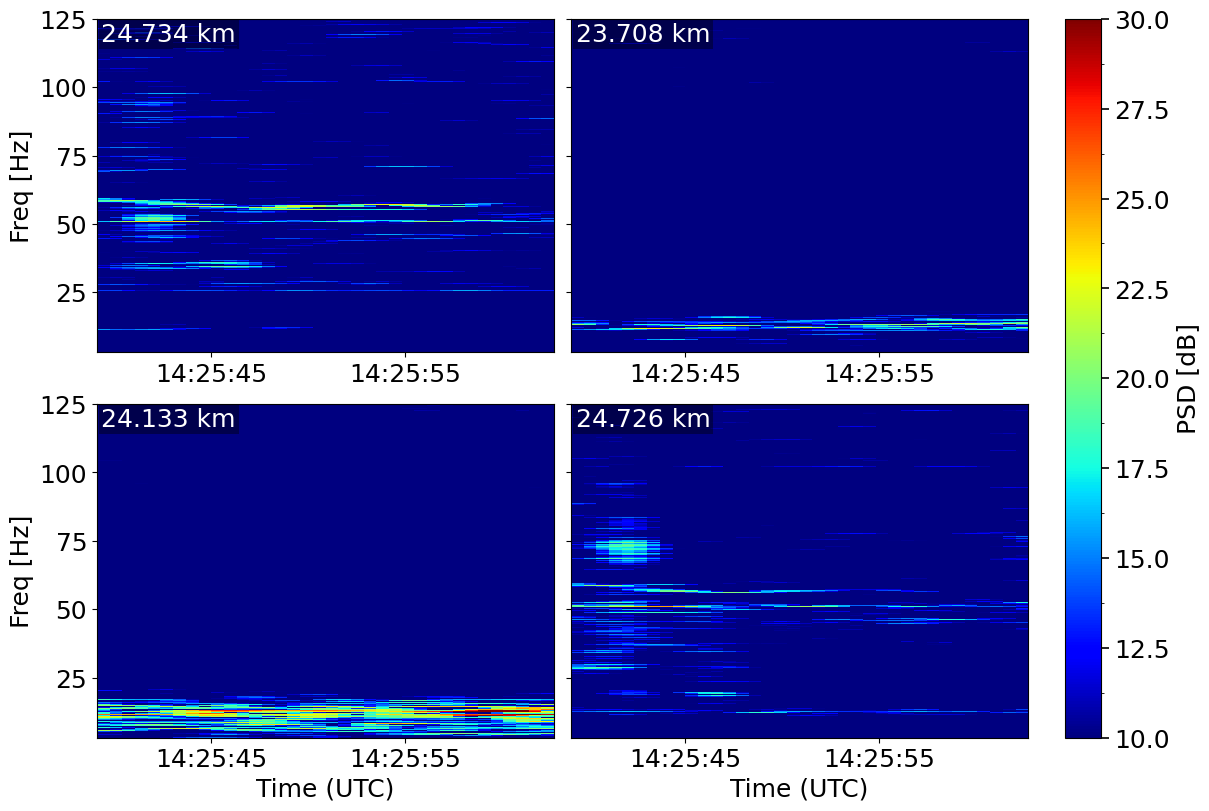

Plotted spectrograms for timestamp 122536 across channels: [24218, 23214, 23630, 24210]


In [42]:
# Spectrograms for one timestamp (122536) across four channel IDs in a 2x2 grid
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator
import h5py

# Reuse DIRECTORY and helpers from above cells
try:
    DIRECTORY
except NameError:
    DIRECTORY = "../raw_data/GC_data/20250702"
file_paths = sorted(glob.glob(os.path.join(DIRECTORY, '*.hdf5')))
if not file_paths:
    raise FileNotFoundError(f"No HDF5 files found in {DIRECTORY}")

TARGET_TIMESTAMP = "122536"
CHANNEL_IDS = [24218, 23214, 23630, 24210]
SPECTROGRAM_CHUNK_SIZE = 3  # 3 files ~30s

# Plot params
fmax = 125
vmin_db = 10
vmax_db = 30
Nfft = 4096
OVERLAP = 0.9
time_tolerance = 0.05

# Helper: map channel ID to index using channels array
def channel_id_to_index(channel_ids_array, dx_val, requested_id):
    matches = np.where(channel_ids_array == requested_id)[0]
    if matches.size > 0:
        return int(matches[0]), False
    # nearest by distance if exact ID not present
    distances_m = channel_ids_array * dx_val
    target_m = requested_id * dx_val
    idx = int(np.argmin(np.abs(distances_m - target_m)))
    return idx, True

def find_start_index(file_paths, ts_str):
    _, start_idx = find_start_file(file_paths, ts_str)
    return start_idx

def load_channel_block_for_timestamp(file_paths, ts_str, requested_channel_id):
    start_idx = find_start_index(file_paths, ts_str)
    sel_paths = file_paths[start_idx : min(start_idx + SPECTROGRAM_CHUNK_SIZE, len(file_paths))]
    if len(sel_paths) < SPECTROGRAM_CHUNK_SIZE:
        print(f"Warning: Only {len(sel_paths)} files found starting at {ts_str}")
    all_channel_data = []
    file_start_time = None
    dt_ref = None
    channels_ref = None
    file_duration = None
    processed_files_count = 0
    dx_last = None
    ch_index_used = None
    ch_id_used = requested_channel_id
    # Determine index for requested channel ID using first file metadata
    s_time0, s_dt0, s_dx0, s_channels0, s_num0 = extract_metadata(sel_paths[0])
    idx0, was_mapped = channel_id_to_index(s_channels0, s_dx0, requested_channel_id)
    ch_index_used = idx0
    if was_mapped:
        print(f"[WARN] Channel ID {requested_channel_id} not found; using nearest at index {idx0} (ID {int(s_channels0[idx0])})")
        ch_id_used = int(s_channels0[idx0])
    for i, fp in enumerate(sel_paths):
        current_start_time, current_dt, dx, current_channels, num_samples = extract_metadata(fp)
        dx_last = dx
        current_file_duration = num_samples * current_dt
        if file_start_time is None:
            file_start_time = current_start_time
            dt_ref = current_dt
            channels_ref = current_channels
            file_duration = current_file_duration
        if not np.isclose(current_dt, dt_ref, atol=1e-12):
            print(f"Skipping {os.path.basename(fp)}: dt mismatch ({current_dt} != {dt_ref})")
            continue
        expected_start = file_start_time + processed_files_count * file_duration
        if not np.isclose(current_start_time, expected_start, atol=time_tolerance):
            print(f"Skipping {os.path.basename(fp)}: start {current_start_time} not contiguous (expected {expected_start})")
            break
        if ch_index_used >= len(current_channels):
            print(f"Selected channel index {ch_index_used} out of range for {os.path.basename(fp)} (max {len(current_channels)-1})")
            break
        with h5py.File(fp, 'r') as f:
            ch_data = f['data'][:, ch_index_used]
            all_channel_data.append(ch_data)
            processed_files_count += 1
    if not all_channel_data:
        return None, None, None, None, None, None
    combined = np.concatenate(all_channel_data)
    fs = 1.0 / dt_ref
    distance_km = (ch_id_used * dx_last) / 1000.0 if dx_last is not None else None
    return combined, fs, dt_ref, file_start_time, distance_km, ch_id_used

# Build 2x2 grid with constrained layout to match Cell 2
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=True, constrained_layout=True)
axes = np.array(axes)
last_im = None

for idx, ch_id in enumerate(CHANNEL_IDS):
    r = idx // 2
    c = idx % 2
    ax = axes[r, c]
    data, fs, dt_ref, file_start_time, distance_km, ch_id_used = load_channel_block_for_timestamp(file_paths, TARGET_TIMESTAMP, ch_id)
    if data is None:
        ax.text(0.5, 0.5, "No data", ha='center', va='center')
        ax.set_axis_off()
        continue
    tspect, fspect, psd = compute_spectrogram(
        data,
        fs,
        Nfft=Nfft,
        overlap=OVERLAP,
        file_time=file_start_time
)
    tspect_num = mdates.date2num(tspect)
    T, F = np.meshgrid(tspect_num, fspect)
    last_im = ax.pcolormesh(T, F, psd, cmap='jet', vmin=vmin_db, vmax=vmax_db, shading='auto')
    ax.set_ylim(3, fmax)
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    # X ticks at 10-second increments to match Cell 2
    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=10))
    # Add km stamp at top-left to match Cell 2 style
    if distance_km is not None:
        ax.text(0.01, 0.99, f"{distance_km:.3f} km", transform=ax.transAxes, ha='left', va='top', fontsize=18, color='white', bbox=dict(facecolor='black', alpha=0.4, edgecolor='none', pad=2))
    # Remove titles for consistency
    # title_id = ch_id if ch_id == ch_id_used else f"{ch_id}→{ch_id_used}"
    # ax.set_title(f"{TARGET_TIMESTAMP} | channel ID {title_id} @ {distance_km:.3f} km", fontsize=10)
    if r == 1:
        ax.set_xlabel('Time (UTC)', fontsize=18)
    if c == 0:
        ax.set_ylabel('Freq [Hz]', fontsize=18)
    # Increase tick label sizes to match Cell 2
    ax.tick_params(axis='both', which='major', labelsize=18)

# Colorbar styled like Cell 2
if last_im is not None:
    cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    cbar.set_label('PSD [dB]', fontsize=18)
    cbar.ax.tick_params(labelsize=18, which='major', length=6, width=1.2)
    cbar.ax.yaxis.set_minor_locator(AutoMinorLocator(2))

plt.show()

print(f"Plotted spectrograms for timestamp {TARGET_TIMESTAMP} across channels: {CHANNEL_IDS}")